<a href="https://colab.research.google.com/github/ItsMeJacob6986/git-journy/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as f

In [49]:
#creat a new model class that inherits nn.module
class Model(nn.Module):
  #input layer (four fatures of the flower) ----> hidden layers 1 ----> to an hidden layer 2
  # -----> hidden layer 3 ---> hidden layer n ----> output.
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()           # this inisialte our nn.module
    self.fcl = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

def forward(self, x):
  x = F.relu(self.fcl(x))
  x - F.relu(self.fcl2(x))
  x = self.out(x)
  return x

In [50]:
#pick a manual seed for randomization
torch.manual_seed(41)
#create an instance of the model
model = Model()

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [52]:
url ='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [53]:
my_df


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [54]:
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [55]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [56]:
# change last colume from strings to intergers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

/tmp/ipykernel_11966/2319597877.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [59]:
#train test split set x,y
x = my_df.drop('species', axis=1)
y = my_df['species']

In [60]:
x = x.values
y = y.values

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [65]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)



In [66]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [69]:
#set the criter of the model to measure the error , how far off the predection are from
criterion = nn.CrossEntropyLoss()
#choose Adam optimiser, ir = Learning rate
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [78]:
# Redefining Model here to fix the indentation and typos from the previous cell
class Model(nn.Module):
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = f.relu(self.fc1(x))
    x = f.relu(self.fc2(x))
    x = self.out(x)
    return x

# Re-initialize the model and optimizer with the corrected class
torch.manual_seed(41)
model = Model()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 100
losses = []
for i in range(epochs):
  # Now model(x_train) will correctly call the forward method
  y_pred = model(x_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  if i % 10 == 0:
    print(f'epoch: {i} loss: {loss.item()}')

  optimiser.zero_grad()
  loss.backward()
  optimiser.step()

epoch: 0 loss: 1.1251550912857056
epoch: 10 loss: 1.0096259117126465
epoch: 20 loss: 0.8157405853271484
epoch: 30 loss: 0.585706353187561
epoch: 40 loss: 0.3999636471271515
epoch: 50 loss: 0.26768800616264343
epoch: 60 loss: 0.17942361533641815
epoch: 70 loss: 0.12151690572500229
epoch: 80 loss: 0.0860118493437767
epoch: 90 loss: 0.06520850956439972


Text(0.5, 0, 'epoch')

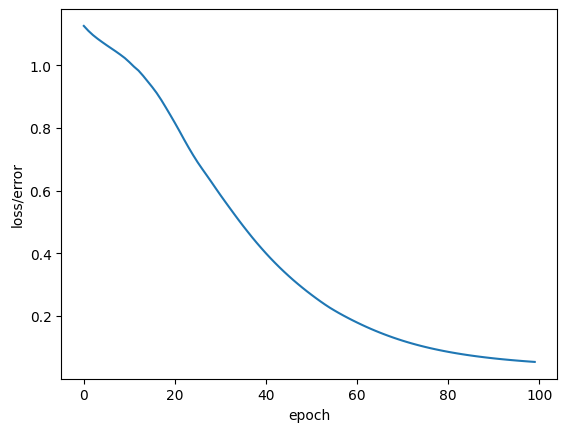

In [79]:
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("epoch")
